In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

print("All imports working")

Matplotlib is building the font cache; this may take a moment.


All imports working


In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
print(X.shape, y.shape)

ImportError: Using `parser='auto'` with dense data requires pandas to be installed. Alternatively, explicitly set `parser='liac-arff'`.

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
print(X.shape, y.shape)


(70000, 784) (70000,)


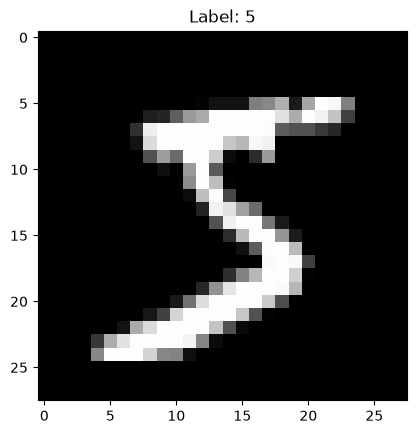

In [4]:
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()


In [5]:
X = X / 255.0

y_onehot = np.zeros((y.size, 10))
y_onehot[np.arange(y.size), y] = 1

In [18]:
def init_params():
    W1 = np.random.randn(32, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((32, 1))
    W2 = np.random.randn(32, 32) * np.sqrt(2 / 32)
    b2 = np.zeros((32, 1))
    W3 = np.random.randn(10, 32) * np.sqrt(2 / 32)
    b3 = np.zeros((10, 1))
    return W1, b1, W2, b2, W3, b3

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)
    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2, Z3, A3

In [9]:
def relu_derivative(z):
    return (z > 0).astype(float)

def backward(X, y_onehot, Z1, A1, Z2, A2, Z3, A3, W2, W3):
    m = X.shape[1]

    dZ3 = A3 - y_onehot
    dW3 = (dZ3 @ A2.T) / m
    db3 = np.sum(dZ3, axis=1, keepdims=True) / m

    dA2 = W3.T @ dZ3
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [10]:
X_train = X.T
y_train = y_onehot.T

print(X_train.shape, y_train.shape)

(784, 70000) (10, 70000)


In [25]:
def train_momentum(X, y_onehot, epochs, learning_rate, batch_size, beta=0.9):
    W1, b1, W2, b2, W3, b3 = init_params()
    m = X.shape[1]

    vW1, vb1 = np.zeros_like(W1), np.zeros_like(b1)
    vW2, vb2 = np.zeros_like(W2), np.zeros_like(b2)
    vW3, vb3 = np.zeros_like(W3), np.zeros_like(b3)

    for epoch in range(epochs):
        permutation = np.random.permutation(m)
        X_shuffled = X[:, permutation]
        y_shuffled = y_onehot[:, permutation]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[:, i:i+batch_size]
            y_batch = y_shuffled[:, i:i+batch_size]

            Z1, A1, Z2, A2, Z3, A3 = forward(X_batch, W1, b1, W2, b2, W3, b3)
            dW1, db1, dW2, db2, dW3, db3 = backward(X_batch, y_batch, Z1, A1, Z2, A2, Z3, A3, W2, W3)

            vW1 = beta * vW1 + (1 - beta) * dW1
            vb1 = beta * vb1 + (1 - beta) * db1
            vW2 = beta * vW2 + (1 - beta) * dW2
            vb2 = beta * vb2 + (1 - beta) * db2
            vW3 = beta * vW3 + (1 - beta) * dW3
            vb3 = beta * vb3 + (1 - beta) * db3

            W1 -= learning_rate * vW1
            b1 -= learning_rate * vb1
            W2 -= learning_rate * vW2
            b2 -= learning_rate * vb2
            W3 -= learning_rate * vW3
            b3 -= learning_rate * vb3

        if epoch % 10 == 0:
            Z1, A1, Z2, A2, Z3, A3 = forward(X, W1, b1, W2, b2, W3, b3)
            predictions = np.argmax(A3, axis=0)
            labels = np.argmax(y_onehot, axis=0)
            accuracy = np.mean(predictions == labels)
            print(f"Epoch {epoch}: accuracy = {accuracy:.4f}")

    return W1, b1, W2, b2, W3, b3

In [15]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

X_train = X_train_raw.T
y_train = y_train_raw.T
X_test = X_test_raw.T
y_test = y_test_raw.T

print(X_train.shape, X_test.shape)

(784, 56000) (784, 14000)


In [26]:
W1, b1, W2, b2, W3, b3 = train_momentum(X_train, y_train, epochs=50, learning_rate=0.01, batch_size=128, beta=0.9)

Epoch 0: accuracy = 0.8339
Epoch 10: accuracy = 0.9339
Epoch 20: accuracy = 0.9485
Epoch 30: accuracy = 0.9571
Epoch 40: accuracy = 0.9634


In [27]:
_, _, _, _, _, A3_test = forward(X_test, W1, b1, W2, b2, W3, b3)
test_predictions = np.argmax(A3_test, axis=0)
test_labels = np.argmax(y_test, axis=0)
test_accuracy = np.mean(test_predictions == test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9559


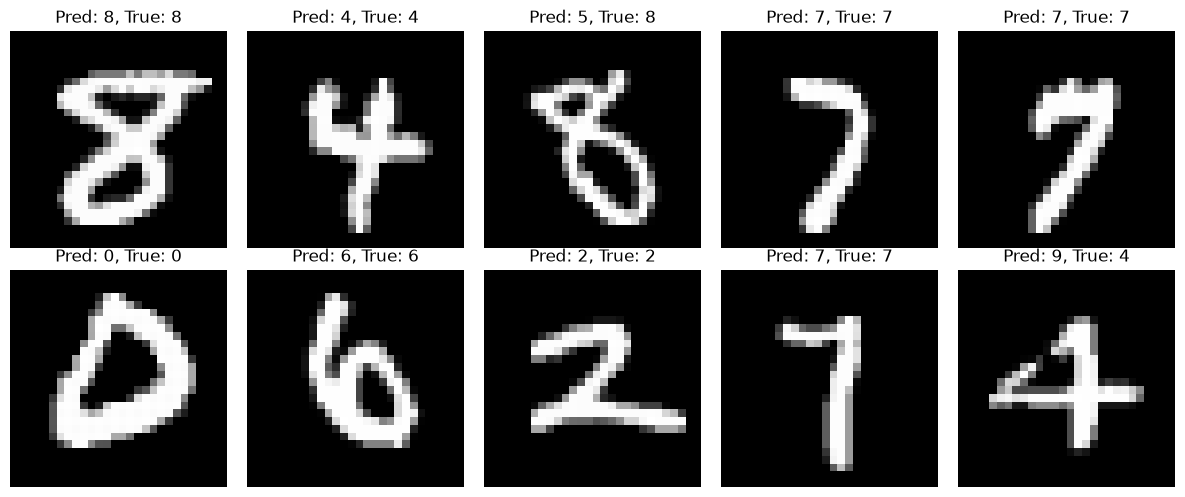

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = X_test[:, i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {test_predictions[i]}, True: {test_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()